# 02 — Bivariate Analysis (Phân tích đa biến đôi)

**Mục tiêu:** Xác định biến Weather nào thực sự liên quan đến AQI — trả lời trực tiếp
giả thuyết nghiệp vụ "thời tiết có dự đoán được chất lượng không khí không?".

Notebook gồm 4 phần:
1. Setup & tái tạo `aqi_category` (giống Notebook 01)
2. Tương quan giữa biến Weather và `us_aqi` (dạng số liên tục)
3. Phân bố biến Weather theo từng nhóm AQI Category (boxplot so sánh)
4. Phân tích theo Thời gian (giờ/mùa) và Địa điểm


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

def aqi_to_category(value):
    if value <= 50:
        return "Good"
    elif value <= 100:
        return "Moderate"
    elif value <= 150:
        return "Unhealthy for Sensitive Groups"
    elif value <= 200:
        return "Unhealthy"
    elif value <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["aqi_category"] = df["us_aqi"].apply(aqi_to_category)
category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
                   "Unhealthy", "Very Unhealthy", "Hazardous"]

# Thêm các đặc trưng thời gian phục vụ phân tích ở phần 4
df["hour"] = df["date"].dt.hour
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# Định nghĩa mùa theo khí hậu Nam Bộ: mùa khô (T11-T4), mùa mưa (T5-T10)
df["season"] = np.where(df["month"].isin([11, 12, 1, 2, 3, 4]), "Mùa khô", "Mùa mưa")

print("Shape:", df.shape)
df.head()


Shape: (263040, 35)


,location_id,location_name,date,pm10,pm2_5,carbon_monoxide,sulphur_dioxide,ozone,nitrogen_dioxide,aerosol_optical_depth,dust,us_aqi_pm2_5,us_aqi_pm10,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_sulphur_dioxide,us_aqi,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,weather_code,sunshine_duration,boundary_layer_height,dew_point_2m,aqi_category,hour,month,day_of_week,is_weekend,season
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,95.0,65.0,993.0,37.50,25.0,84.40,0.29,0.0,133.11458,58.687496,41.568165,9.687199,24.002783,20.447111,133.11458,23.85,61.484700,0.0,1013.40027,100.0,11.304229,9.162280,3.0,0.0,70.0,16.0,Unhealthy for Sensitive Groups,0,1,Sunday,True,Mùa khô
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,86.1,59.0,846.0,30.75,28.0,70.25,0.25,0.0,132.65625,58.570840,34.599094,10.109903,18.784786,16.766632,132.65625,23.30,62.749770,0.0,1013.19920,100.0,10.739833,13.570457,3.0,0.0,80.0,15.8,Unhealthy for Sensitive Groups,1,1,Sunday,True,Mùa khô
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,83.4,57.0,821.0,28.90,26.0,65.80,0.24,0.0,131.73958,58.312500,32.407406,10.200483,14.784323,15.757906,131.73958,22.75,64.459640,0.0,1012.69824,100.0,8.287822,2.489499,3.0,0.0,105.0,15.7,Unhealthy for Sensitive Groups,2,1,Sunday,True,Mùa khô
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,80.1,54.8,834.0,28.45,22.0,63.95,0.24,0.0,130.64583,58.002083,31.496256,10.055555,12.117347,15.512541,130.64583,22.25,65.602090,0.0,1012.29730,100.0,8.669949,4.763556,3.0,0.0,135.0,15.5,Unhealthy for Sensitive Groups,3,1,Sunday,True,Mùa khô
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,69.4,47.5,838.0,27.20,20.0,60.10,0.23,0.0,129.43752,57.658333,29.600079,9.801933,11.421614,14.830973,129.43752,21.95,66.812325,0.0,1012.19680,100.0,7.928178,357.397500,3.0,0.0,145.0,15.5,Unhealthy for Sensitive Groups,4,1,Sunday,True,Mùa khô


## 2. Tương quan giữa biến Weather và `us_aqi`

Dùng Pearson correlation (vì `us_aqi` ở dạng số liên tục tại bước này, trước khi rời rạc hóa).


In [2]:
weather_numeric_cols = [
    "temperature_2m", "relative_humidity_2m", "rain", "surface_pressure",
    "cloud_cover", "wind_speed_10m", "wind_direction_10m",
    "sunshine_duration", "boundary_layer_height", "dew_point_2m",
]

corr_with_aqi = df[weather_numeric_cols + ["us_aqi"]].corr()["us_aqi"].drop("us_aqi").sort_values()
corr_with_aqi


wind_speed_10m          -0.292875
boundary_layer_height   -0.086048
temperature_2m          -0.014721
sunshine_duration       -0.012379
rain                     0.013580
relative_humidity_2m     0.040090
dew_point_2m             0.040860
cloud_cover              0.053145
wind_direction_10m       0.116283
surface_pressure         0.119881
Name: us_aqi, dtype: float64

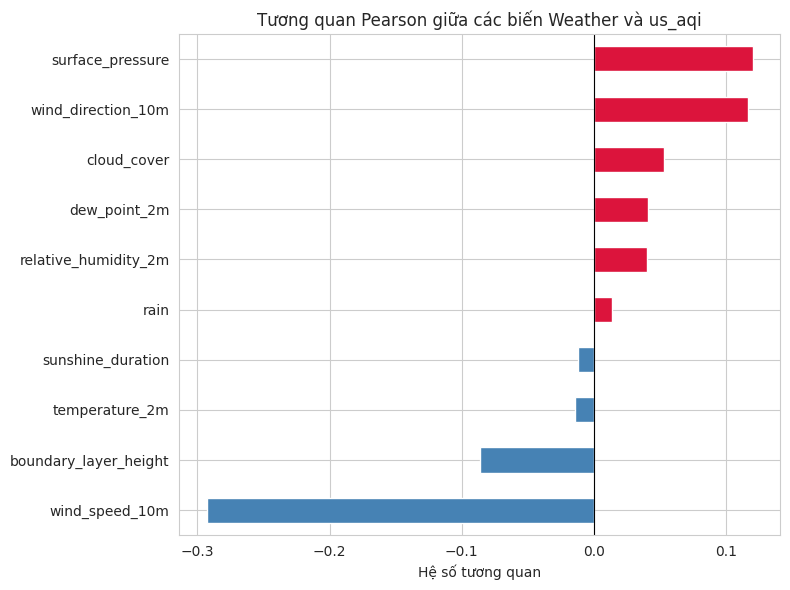

In [3]:
plt.figure(figsize=(8, 6))
corr_with_aqi.plot(kind="barh", color=["crimson" if v > 0 else "steelblue" for v in corr_with_aqi])
plt.title("Tương quan Pearson giữa các biến Weather và us_aqi")
plt.xlabel("Hệ số tương quan")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**Diễn giải nghiệp vụ cần điền sau khi chạy:**
- Biến nào tương quan dương mạnh nhất? (Giả thuyết: nồng độ ô nhiễm tăng khi điều kiện khuếch tán kém)
- Biến nào tương quan âm mạnh nhất? (Giả thuyết: `wind_speed_10m`, `boundary_layer_height` cao → AQI thấp, vì gió/lớp biên giúp khuếch tán ô nhiễm)
- Tương quan có **yếu** (gần 0) ở biến nào? → biến đó có thể ít giá trị dự đoán đơn lẻ, nhưng vẫn có thể hữu ích khi kết hợp (tree-based model bắt được tương tác phi tuyến).


## 3. Phân bố biến Weather theo từng nhóm AQI Category

Đây là phân tích quan trọng nhất cho bài toán Classification — kiểm tra biến Weather
có **phân tách rõ rệt** giữa các nhóm AQI hay không.


/tmp/ipykernel_727/3707060912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="aqi_category", y=col, order=category_order, ax=axes[i], palette="YlOrRd")


/tmp/ipykernel_727/3707060912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="aqi_category", y=col, order=category_order, ax=axes[i], palette="YlOrRd")


/tmp/ipykernel_727/3707060912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="aqi_category", y=col, order=category_order, ax=axes[i], palette="YlOrRd")


/tmp/ipykernel_727/3707060912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="aqi_category", y=col, order=category_order, ax=axes[i], palette="YlOrRd")


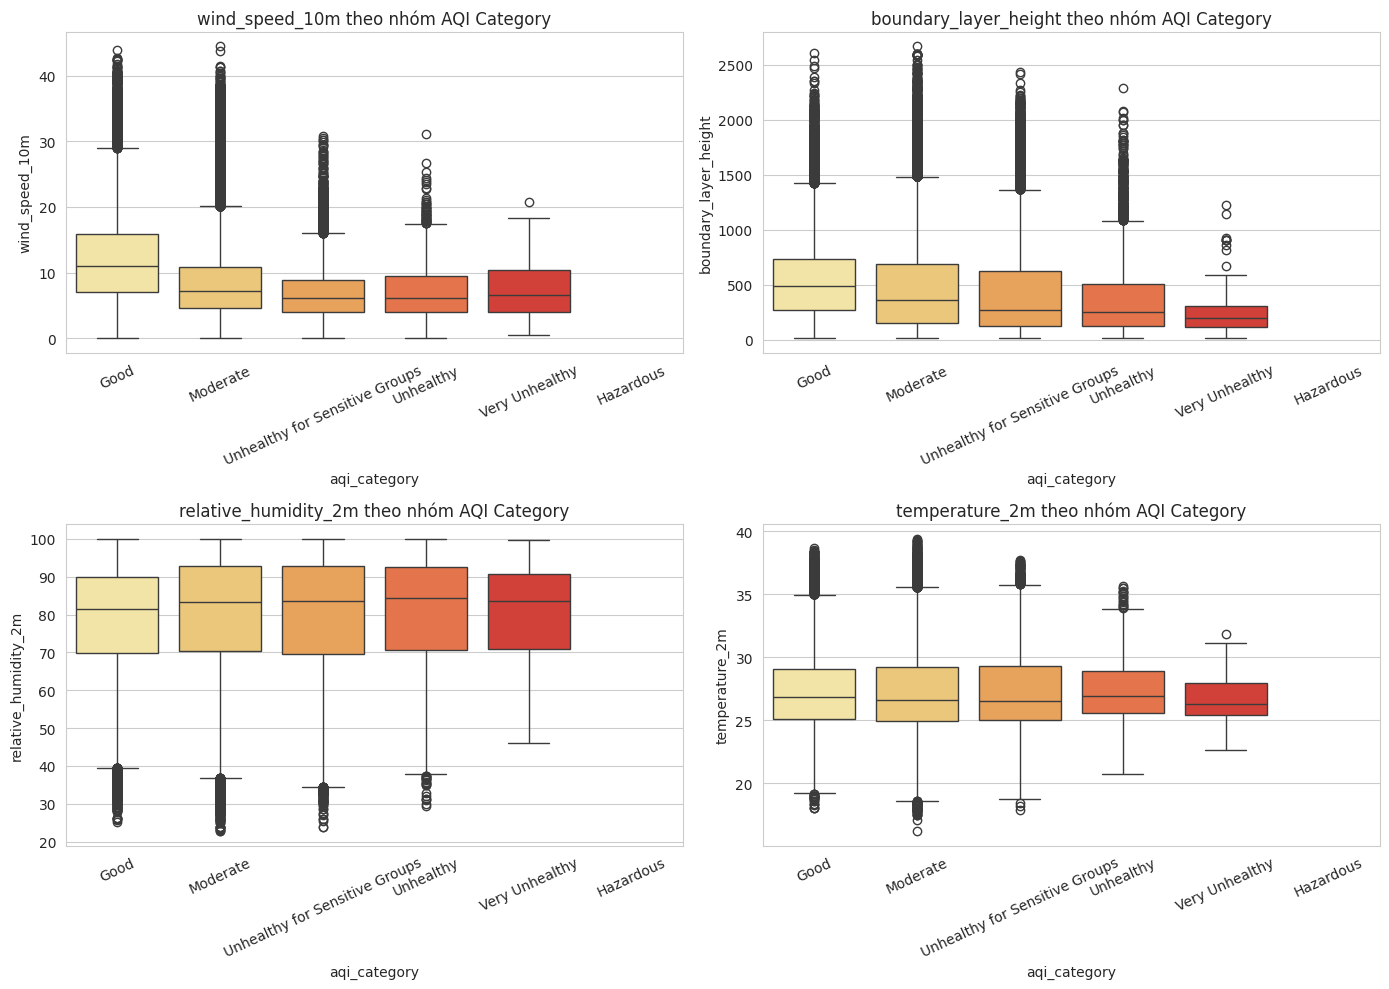

In [4]:
key_weather_vars = ["wind_speed_10m", "boundary_layer_height", "relative_humidity_2m", "temperature_2m"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_weather_vars):
    sns.boxplot(data=df, x="aqi_category", y=col, order=category_order, ax=axes[i], palette="YlOrRd")
    axes[i].set_title(f"{col} theo nhóm AQI Category")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


In [5]:
# Kiểm định thống kê: biến Weather có khác biệt có ý nghĩa giữa các nhóm AQI không?
# Dùng ANOVA (so sánh trung bình nhiều nhóm)
print("Kiểm định ANOVA — H0: trung bình biến giống nhau giữa các nhóm AQI Category\n")

for col in weather_numeric_cols:
    groups = [df[df["aqi_category"] == cat][col].dropna() for cat in category_order]
    # Loại các nhóm rỗng (ví dụ "Hazardous" có thể không xuất hiện trong dữ liệu thực tế) —
    # f_oneway trả về nan cho TOÀN BỘ kết quả nếu có 1 group rỗng truyền vào, dù các group
    # còn lại đều hợp lệ.
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        print(f"{col:<25} không đủ nhóm có dữ liệu để kiểm định")
        continue
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "có ý nghĩa (p<0.05)" if p_value < 0.05 else "KHÔNG có ý nghĩa"
    print(f"{col:<25} F={f_stat:>10.2f}  p={p_value:.4e}  -> {significance}")


Kiểm định ANOVA — H0: trung bình biến giống nhau giữa các nhóm AQI Category

temperature_2m            F=     11.18  p=4.5874e-09  -> có ý nghĩa (p<0.05)
relative_humidity_2m      F=     70.79  p=4.9576e-60  -> có ý nghĩa (p<0.05)
rain                      F=     15.30  p=1.6336e-12  -> có ý nghĩa (p<0.05)


surface_pressure          F=    679.35  p=0.0000e+00  -> có ý nghĩa (p<0.05)
cloud_cover               F=    173.87  p=5.1946e-149  -> có ý nghĩa (p<0.05)
wind_speed_10m            F=   6228.32  p=0.0000e+00  -> có ý nghĩa (p<0.05)
wind_direction_10m        F=    812.05  p=0.0000e+00  -> có ý nghĩa (p<0.05)


sunshine_duration         F=     10.82  p=9.0122e-09  -> có ý nghĩa (p<0.05)
boundary_layer_height     F=    270.62  p=1.7900e-232  -> có ý nghĩa (p<0.05)
dew_point_2m              F=     81.54  p=2.7373e-69  -> có ý nghĩa (p<0.05)


**Diễn giải:** biến có p-value < 0.05 nghĩa là trung bình của biến đó **khác biệt có ý nghĩa thống kê**
giữa các nhóm AQI — đây là ứng viên feature tốt cho mô hình Classification. Biến có p-value lớn (không có ý nghĩa)
không có nghĩa là vô dụng hoàn toàn (vẫn có thể hữu ích khi kết hợp nhiều biến), nhưng tương quan đơn biến yếu.


## 4. Phân tích theo Thời gian

### 4.1. AQI trung bình theo giờ trong ngày — kiểm tra pattern giờ cao điểm

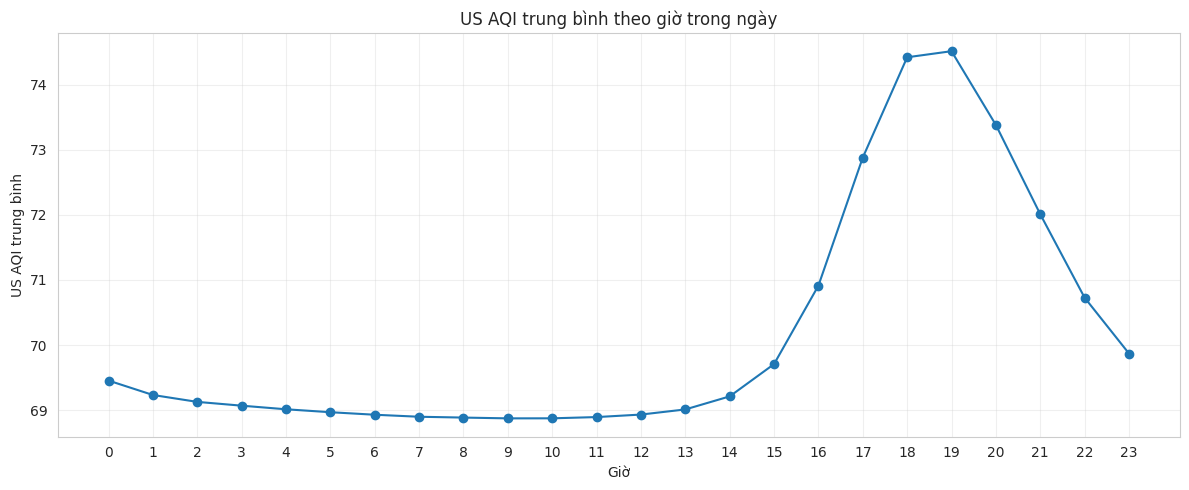

In [6]:
hourly_aqi = df.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(12, 5))
hourly_aqi.plot(marker="o")
plt.title("US AQI trung bình theo giờ trong ngày")
plt.xlabel("Giờ")
plt.ylabel("US AQI trung bình")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.2. AQI trung bình theo mùa (mùa khô vs mùa mưa)

/tmp/ipykernel_727/2330444754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="season", y="us_aqi", palette="Set2")


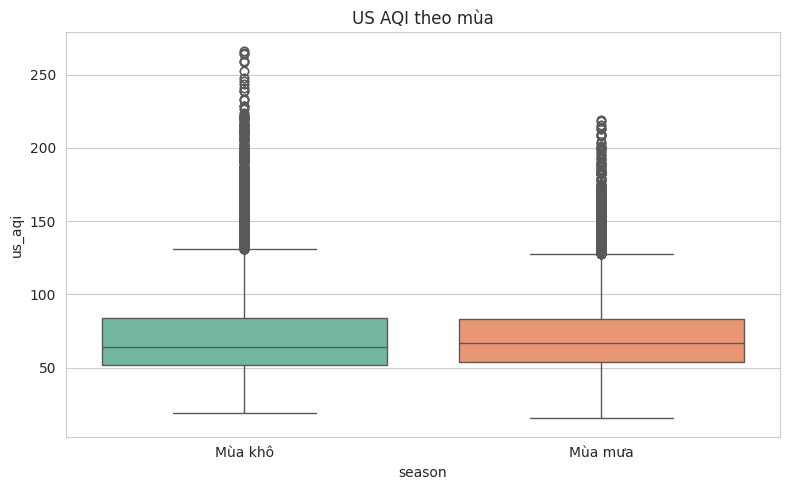

              mean     median        std
season                                  
Mùa khô  69.799352  63.945038  26.023515
Mùa mưa  70.510676  66.950350  24.835399


In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="season", y="us_aqi", palette="Set2")
plt.title("US AQI theo mùa")
plt.tight_layout()
plt.show()

print(df.groupby("season")["us_aqi"].agg(["mean", "median", "std"]))


### 4.3. AQI theo ngày trong tuần (cuối tuần vs ngày thường)

/tmp/ipykernel_727/1020947581.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_weekend", y="us_aqi", palette="Set3")


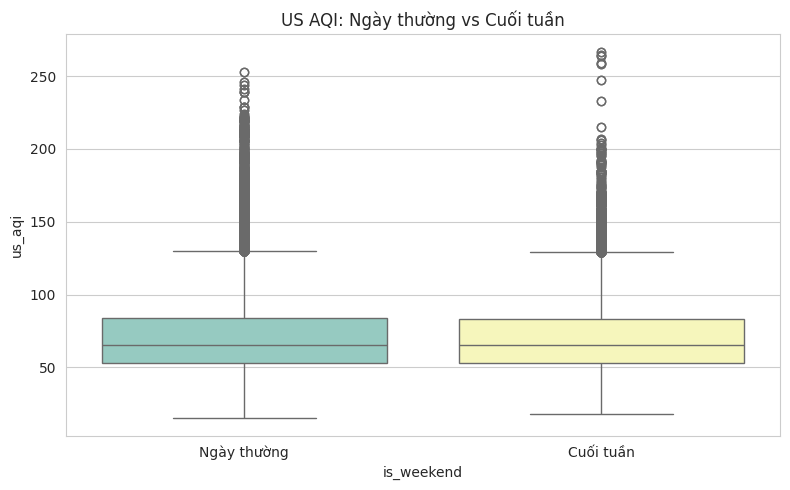

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_weekend", y="us_aqi", palette="Set3")
plt.xticks([0, 1], ["Ngày thường", "Cuối tuần"])
plt.title("US AQI: Ngày thường vs Cuối tuần")
plt.tight_layout()
plt.show()


## 5. Phân tích theo Địa điểm

/tmp/ipykernel_727/1377614844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="location_name", y="us_aqi", order=order_by_median, palette="coolwarm")


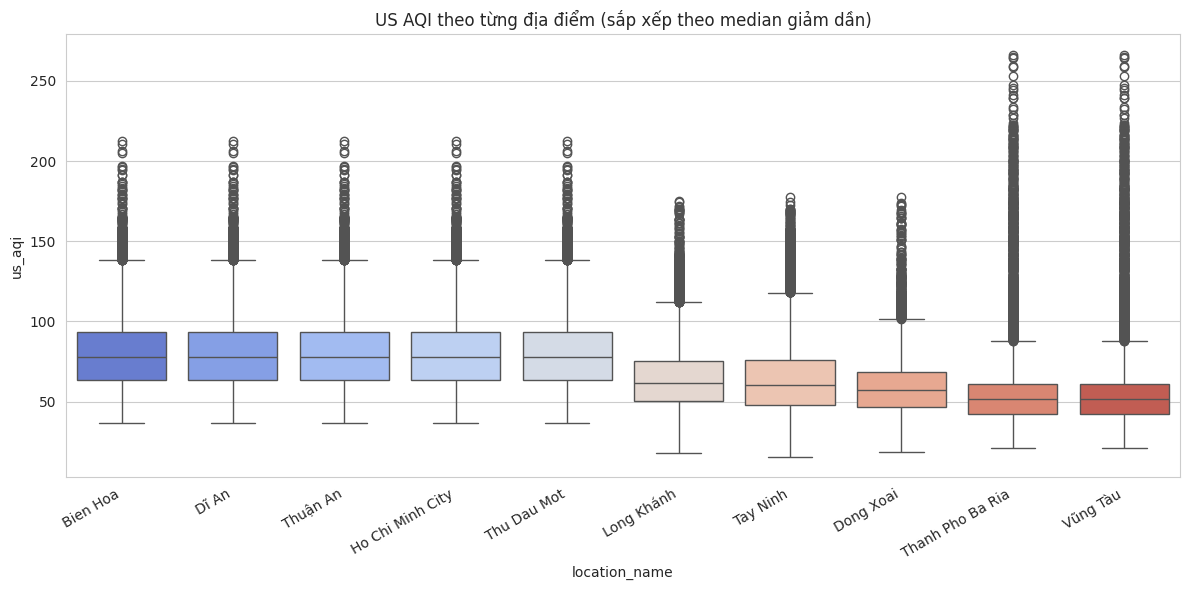

In [9]:
plt.figure(figsize=(12, 6))
order_by_median = df.groupby("location_name")["us_aqi"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="location_name", y="us_aqi", order=order_by_median, palette="coolwarm")
plt.title("US AQI theo từng địa điểm (sắp xếp theo median giảm dần)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [10]:
df.groupby("location_name")["us_aqi"].agg(["mean", "median", "std", "max"]).sort_values("mean", ascending=False)


,mean,median,std,max
location_name,,,,
Bien Hoa,81.038288,77.584220,23.965472,212.32547
Dĩ An,81.038288,77.584220,23.965472,212.32547
Thuận An,81.038288,77.584220,23.965472,212.32547
Ho Chi Minh City,81.038288,77.584220,23.965472,212.32547
Thu Dau Mot,81.038288,77.584220,23.965472,212.32547
Tay Ninh,64.948930,60.385640,25.587509,177.45535
Long Khánh,63.397772,61.338650,19.607274,175.22322
Dong Xoai,58.402661,57.092200,17.902864,177.77423
Thanh Pho Ba Ria,54.817648,51.648937,21.958290,266.43396


---
## Tổng kết Notebook 02

Checklist trước khi sang `03_multivariate_analysis.ipynb`:
- [ ] Đã xác định top biến Weather tương quan mạnh nhất với `us_aqi` (cả dương và âm)
- [ ] Đã kiểm định ANOVA — biết rõ biến nào phân tách tốt giữa 6 nhóm AQI
- [ ] Đã xác nhận/phủ nhận pattern giờ cao điểm, mùa khô/mưa, cuối tuần
- [ ] Đã xếp hạng địa điểm theo mức độ ô nhiễm trung bình
